Final Practical - Python - 5/9/2026 - derave1577

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import simpy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "derave1577"
display(Markdown("### Step 1: Define the Simulation Environment"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
def customer(env, name, counter, movie_duration, data_log, staff_level):
    """Customer arrives, waits for service, and stays for the movie."""
    arrival_time = env.now   
    with counter.request() as request:
        # Wait for an available ticket counter employee
        yield request
        wait_time = env.now - arrival_time     
        # Log the simulation data
        data_log.append({
            'Staffing Level': staff_level,
            'Customer': name,
            'Arrival Time': arrival_time,
            'Wait Time': wait_time
        })   
        # Service Time
        yield env.timeout(6)     
    # Process: Watching the movie
    yield env.timeout(movie_duration)
def setup(env, num_employees, inter_arrival, movie_duration, max_customers, data_log):
    """Theater setup: creates employees and generates customers at intervals."""
    counter = simpy.Resource(env, num_employees)
    for i in range(max_customers):
        yield env.timeout(inter_arrival)
        env.process(customer(env, f'Customer_{i+1}', counter, movie_duration, data_log, num_employees))

### Step 1: Define the Simulation Environment

Date: 2026-05-09

Student ID: derave1577

In [2]:
display(Markdown("### Step 2: Impliment the Simulation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# List to store all logs before converting to DataFrame
simulation_results = []
# Parameters from your request
STAFFING_CASES = [1, 2, 3]
MOVIE_DURATION = 120
INTER_ARRIVAL = 5
SIM_TIME = 480
MAX_CUSTOMERS = 50
# Execute the simulation for each staffing case
for staff in STAFFING_CASES:
    # Set random seed for reproducibility per scenario
    np.random.seed(42)   
    env = simpy.Environment()
    env.process(setup(env, staff, INTER_ARRIVAL, MOVIE_DURATION, MAX_CUSTOMERS, simulation_results))
    env.run(until=SIM_TIME)
# Store simulation data in a pandas DataFrame
df = pd.DataFrame(simulation_results)
# Display the final DataFrame and a quick summary
display(Markdown("### Simulation Results Summary"))
print(df.groupby('Staffing Level')['Wait Time'].describe())
display(df.head(10))

### Step 2: Impliment the Simulation

Date: 2026-05-09

Student ID: derave1577

### Simulation Results Summary

                count  mean       std  min    25%   50%    75%   max
Staffing Level                                                      
1                50.0  24.5  14.57738  0.0  12.25  24.5  36.75  49.0
2                50.0   0.0   0.00000  0.0   0.00   0.0   0.00   0.0
3                50.0   0.0   0.00000  0.0   0.00   0.0   0.00   0.0


,Staffing Level,Customer,Arrival Time,Wait Time
0,1,Customer_1,5,0
1,1,Customer_2,10,1
2,1,Customer_3,15,2
3,1,Customer_4,20,3
4,1,Customer_5,25,4
5,1,Customer_6,30,5
6,1,Customer_7,35,6
7,1,Customer_8,40,7
8,1,Customer_9,45,8
9,1,Customer_10,50,9


### Step 3: Analyze the Simulation Results

Date: 2026-05-09

Student ID: derave1577

### Average Customer Wait Times

Employees: 1 | Average Wait: 24.50 minutes
Employees: 2 | Average Wait: 0.00 minutes
Employees: 3 | Average Wait: 0.00 minutes


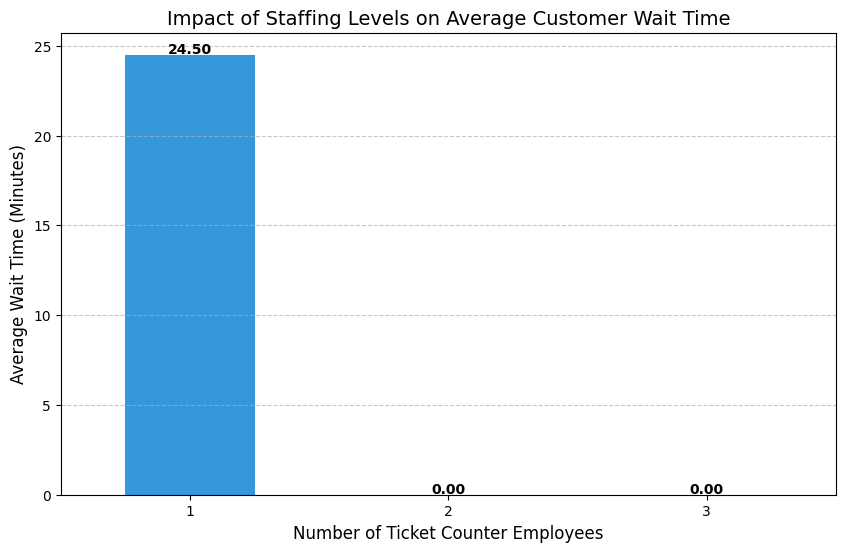

In [3]:
display(Markdown("### Step 3: Analyze the Simulation Results"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Calculate the average wait times for each staffing level
avg_wait_times = df.groupby('Staffing Level')['Wait Time'].mean()
# Display the numerical results
display(Markdown("### Average Customer Wait Times"))
for staff, avg in avg_wait_times.items():
    print(f"Employees: {staff} | Average Wait: {avg:.2f} minutes")
# Create a bar chart for visualization
plt.figure(figsize=(10, 6))
avg_wait_times.plot(kind='bar', color=['#3498db', '#9b59b6', '#2ecc71'])
# Chart Styling
plt.title('Impact of Staffing Levels on Average Customer Wait Time', fontsize=14)
plt.xlabel('Number of Ticket Counter Employees', fontsize=12)
plt.ylabel('Average Wait Time (Minutes)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add value labels on top of bars for clarity
for i, v in enumerate(avg_wait_times):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

In [4]:
display(Markdown("### Step 4: Machine Learning Implimentation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Ensure the 'Inter-arrival Time' column exists in the current df
if 'Inter-arrival Time' not in df.columns:
    df['Inter-arrival Time'] = 5 
# Preprocessing
X = df[['Staffing Level', 'Inter-arrival Time']]
y = df['Wait Time']
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
# Implement Linear Regression with GridSearchCV
param_grid = {'fit_intercept': [True, False]}
grid_search = GridSearchCV(LinearRegression(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
# Evaluate and Display Results
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

### Step 4: Machine Learning Implimentation

Date: 2026-05-09

Student ID: derave1577

Mean Squared Error (MSE): 71.9585
R-squared: 0.6033
Best Parameters: {'fit_intercept': True}


### Step 5: Visualize Predicted Wait Times

Date: 2026-05-09

Student ID: derave1577

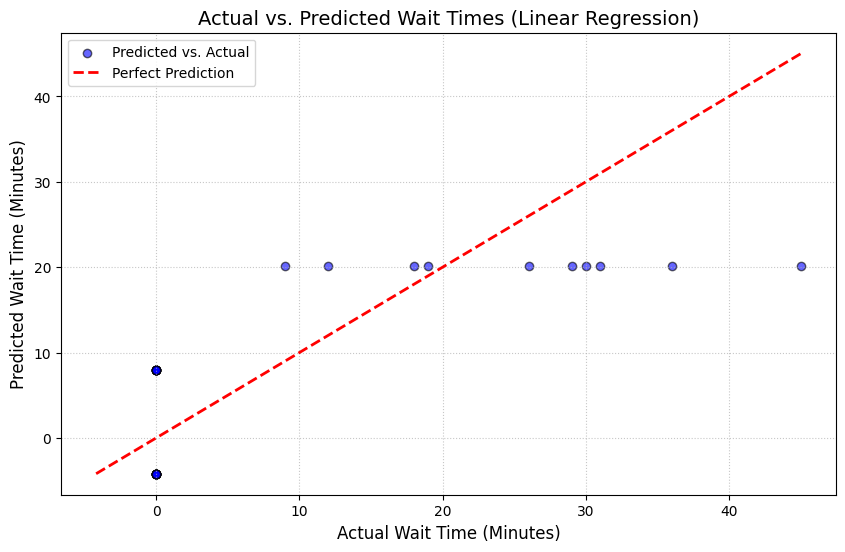

In [6]:
display(Markdown("### Step 5: Visualize Predicted Wait Times"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='k', label='Predicted vs. Actual')
# Add a diagonal line for reference (Ideal fit)
limit_max = max(y_test.max(), y_pred.max())
limit_min = min(y_test.min(), y_pred.min())
plt.plot([limit_min, limit_max], [limit_min, limit_max], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
# Labels and Styling
plt.title('Actual vs. Predicted Wait Times (Linear Regression)', fontsize=14)
plt.xlabel('Actual Wait Time (Minutes)', fontsize=12)
plt.ylabel('Predicted Wait Time (Minutes)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Step 6: Apply Sensitivity Analysis

Date: 2026-05-09

Student ID: derave1577

### Updated Simulation Results Summary

                                 count  mean        std  min    25%   50%  \
Staffing Level Arrival Scenario                                             
1              3                  50.0  73.5  43.732139  0.0  36.75  73.5   
               5                  50.0  24.5  14.577380  0.0  12.25  24.5   
2              3                  50.0   0.0   0.000000  0.0   0.00   0.0   
               5                  50.0   0.0   0.000000  0.0   0.00   0.0   
3              3                  50.0   0.0   0.000000  0.0   0.00   0.0   
               5                  50.0   0.0   0.000000  0.0   0.00   0.0   

                                    75%    max  
Staffing Level Arrival Scenario                 
1              3                 110.25  147.0  
               5                  36.75   49.0  
2              3                   0.00    0.0  
               5                   0.00    0.0  
3              3                   0.00    0.0  
               5                   0.00 

,Staffing Level,Arrival Scenario,Customer,Arrival Time,Wait Time
0,1,5,Customer_1,5,0
1,1,5,Customer_2,10,1
2,1,5,Customer_3,15,2
3,1,5,Customer_4,20,3
4,1,5,Customer_5,25,4
5,1,5,Customer_6,30,5
6,1,5,Customer_7,35,6
7,1,5,Customer_8,40,7
8,1,5,Customer_9,45,8
9,1,5,Customer_10,50,9


### Updated Average Customer Wait Times

Employees: 1 | 5 Min Avg Wait: 24.50 min | 3 Min Avg Wait: 73.50 min
Employees: 2 | 5 Min Avg Wait: 0.00 min | 3 Min Avg Wait: 0.00 min
Employees: 3 | 5 Min Avg Wait: 0.00 min | 3 Min Avg Wait: 0.00 min


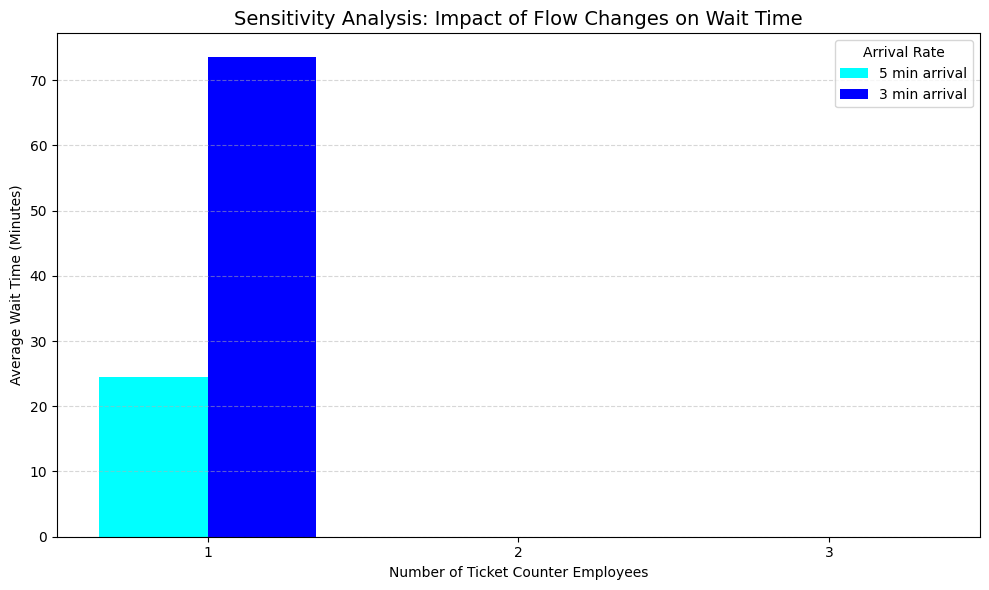

In [15]:
display(Markdown("### Step 6: Apply Sensitivity Analysis"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
def customer(env, name, counter, movie_duration, data_log, staff_level, arrival_rate):
    """Customer arrives, waits for service, and stays for the movie."""
    arrival_time = env.now   
    with counter.request() as request:
        # Wait for an available ticket counter employee
        yield request
        wait_time = env.now - arrival_time     
        # Log the simulation data
        data_log.append({
            'Staffing Level': staff_level,
            'Arrival Scenario': arrival_rate,
            'Customer': name,
            'Arrival Time': arrival_time,
            'Wait Time': wait_time
        })   
        # Service Time
        yield env.timeout(6)     
    # Process: Watching the movie
    yield env.timeout(movie_duration)
def setup(env, num_employees, inter_arrival, movie_duration, max_customers, data_log):
    """Theater setup: creates employees and generates customers at intervals."""
    counter = simpy.Resource(env, num_employees)
    for i in range(max_customers):
        yield env.timeout(inter_arrival)
        env.process(customer(env, f'Customer_{i+1}', counter, movie_duration, data_log, num_employees, inter_arrival))
        # List to store all logs before converting to DataFrame
updated_simulation_results = []
# Parameters
STAFFING_CASES = [1, 2, 3]
MOVIE_DURATION = 120
INTER_ARRIVAL = 3
SIM_TIME = 480
MAX_CUSTOMERS = 50
ARRIVAL_SCENARIOS = [5, 3] # 5 min original time, 3 min new time
# Execute the simulation for each staffing case under both arrival conditions
for arrival_rate in ARRIVAL_SCENARIOS:
    for staff in STAFFING_CASES:
        # Set random seed for reproducibility per scenario
        np.random.seed(42)
        env = simpy.Environment()
        env.process(setup(env, staff, arrival_rate, MOVIE_DURATION, MAX_CUSTOMERS, updated_simulation_results))
        env.run(until=SIM_TIME)
# Store simulation data in a pandas DataFrame
updated_df = pd.DataFrame(updated_simulation_results)
# Display the final DataFrame and a quick summary
display(Markdown("### Updated Simulation Results Summary"))
print(updated_df.groupby(['Staffing Level', 'Arrival Scenario'])['Wait Time'].describe())
display(updated_df.head(10))
# Calculate the average wait times for each staffing level
updated_avg_wait_times = updated_df.groupby(['Staffing Level', 'Arrival Scenario'])['Wait Time'].mean().unstack()
# Rename columns from [5, 3] to ['5 min', '3 min'] to match plotting keys perfectly
updated_avg_wait_times = updated_avg_wait_times.rename(columns={5: '5 min', 3: '3 min'})
# Display the numerical results
display(Markdown("### Updated Average Customer Wait Times"))
# Loop over the index rows (Staffing Levels) instead of columns
for staff in updated_avg_wait_times.index:
    avg_5min = updated_avg_wait_times.loc[staff, '5 min']
    avg_3min = updated_avg_wait_times.loc[staff, '3 min']
    print(f"Employees: {staff} | 5 Min Avg Wait: {avg_5min:.2f} min | 3 Min Avg Wait: {avg_3min:.2f} min")
# Create a grouped bar chart for visualization
fig, ax = plt.subplots(figsize=(10, 6))
staffing_labels = [str(x) for x in updated_avg_wait_times.index]
# Position of groups on x-axis
x = np.arange(len(staffing_labels)) 
# Bar width
width = 0.35
# Extract vectors for plotting
wait_times_5min = updated_avg_wait_times['5 min'].values
wait_times_3min = updated_avg_wait_times['3 min'].values
# Plot bars side by side using positional offsets
rects1 = ax.bar(x - width/2, wait_times_5min, width, label='5 min arrival', color='cyan')
rects2 = ax.bar(x + width/2, wait_times_3min, width, label='3 min arrival', color='blue')
ax.set_title('Sensitivity Analysis: Impact of Flow Changes on Wait Time', fontsize=14)
ax.set_xlabel('Number of Ticket Counter Employees')
ax.set_ylabel('Average Wait Time (Minutes)')
ax.set_xticks(x)
ax.set_xticklabels(staffing_labels)
ax.legend(title="Arrival Rate")
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()